In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

def generate_weather_data(days=1000):
    np.random.seed(42)

    time = np.arange(0, days)
    temp = 20 + 10 * np.sin(2 * np.pi * time / 365) + np.random.normal(0, 2, days)

    df = pd.DataFrame({
        'date': pd.date_range(start='2020-01-01', periods=days, freq='D'),
        'temperature': temp
    })

    return df

df = generate_weather_data()
print(df.head())

        date  temperature
0 2020-01-01    20.993428
1 2020-01-02    19.895605
2 2020-01-03    21.639593
3 2020-01-04    23.562256
4 2020-01-05    20.219718


In [2]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df['temperature'].values.reshape(-1, 1))

def create_sequences(data, seq_length):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(x), np.array(y)

SEQ_LENGTH = 30

X, y = create_sequences(scaled_data, SEQ_LENGTH)

train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Training shape: {X_train.shape}, Testing shape: {X_test.shape}")

Training shape: (776, 30, 1), Testing shape: (194, 30, 1)


In [4]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(SEQ_LENGTH, 1)),
    Dropout(0.2),

    LSTM(50, return_sequences=False),
    Dropout(0.2),

    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=20,
    validation_split=0.1,
    shuffle=False
)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 0.0986 - val_loss: 0.0734
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0263 - val_loss: 0.0127
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0120 - val_loss: 0.0060
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0091 - val_loss: 0.0051
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0082 - val_loss: 0.0052
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0080 - val_loss: 0.0060
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0083 - val_loss: 0.0074
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0078 - val_loss: 0.0069
Epoch 9/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0081 - val_loss: 0.0103
Epoch 10/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0080 - val_loss: 0.0107
Epoch 11/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0077 - val_loss: 0.0116
Epoch 12/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


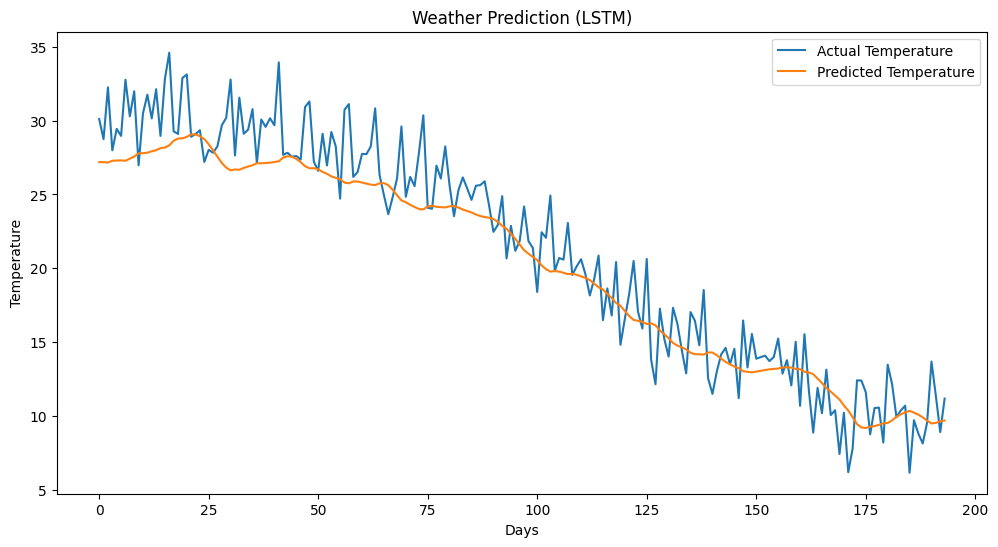

In [12]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)
y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1))

plt.figure(figsize=(12, 6))

plt.plot(y_test_unscaled, label='Actual Temperature')
plt.plot(predictions, label='Predicted Temperature')

plt.title('Weather Prediction (LSTM)')
plt.xlabel('Days')
plt.ylabel('Temperature')

plt.legend()
plt.show()

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_true = y_test_unscaled.flatten()
y_pred = predictions.flatten()

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f} °C")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} °C")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 1.90 °C
Root Mean Squared Error (RMSE): 2.45 °C
R² Score: 0.8974
